In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
# loading dataset
df=pd.read_csv('Titanic-Dataset.csv')




In [43]:
# Save original dataset
df_original = df.copy()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [44]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [45]:
#handling missing values
df["Age"]=df["Age"].fillna(df["Age"].median())
df.drop("Cabin",axis=1, inplace=True)
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [46]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])


In [47]:

df.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

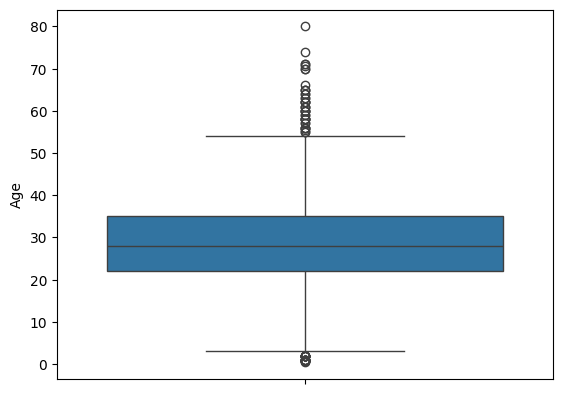

In [48]:
sb.boxplot(df["Age"])
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df["Age"]>=lower) & (df["Age"]<=upper)]


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Age","Fare"]] = scaler.fit_transform(df[["Age","Fare"]])

In [50]:
# Create FamilySize first
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
# Create FarePerPerson
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]
df["IsAlone"] = np.where(df["FamilySize"]==1,1,0)


In [51]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 35, 60, 100],
    labels=["Child", "Teen", "Adult", "MiddleAge", "Senior"]
)

In [52]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["AgeGroup"] = le.fit_transform(df["AgeGroup"])

In [53]:
# before and after comparison of the data
summary = pd.DataFrame({
    "Feature": ["Rows", "Columns", "Missing Values"],
    "Before": [
        df_original.shape[0],
        df_original.shape[1],
        df_original.isnull().sum().sum()
    ],
    "After": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum()
    ]
})

summary

,Feature,Before,After
0,Rows,891,825
1,Columns,12,12
2,Missing Values,866,0


In [41]:
changes = pd.DataFrame({
    "Step": [
        "Missing Values",
        "Categorical Encoding",
        "Outlier Removal",
        "Feature Scaling",
        "Feature Engineering"
    ],
    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

changes

,Step,Status
0,Missing Values,Completed
1,Categorical Encoding,Completed
2,Outlier Removal,Completed
3,Feature Scaling,Completed
4,Feature Engineering,Completed
